# Restaurant Data Analysis Project
### Internship Project using Python

# 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Dataset.csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# 2. Data Understanding and Cleaning

In [2]:
df.shape


(9551, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [4]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [5]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

# Task 1 — Top Cuisines Analysis

In [7]:
df["Cuisines"].head(10)

0            French, Japanese, Desserts
1                              Japanese
2      Seafood, Asian, Filipino, Indian
3                       Japanese, Sushi
4                      Japanese, Korean
5                               Chinese
6                       Asian, European
7    Seafood, Filipino, Asian, European
8               European, Asian, Indian
9                              Filipino
Name: Cuisines, dtype: object

In [8]:
all_cuisines=[]
for cuisines in df["Cuisines"].dropna():
    cuisine_list= cuisines.split(",")
    for cuisine in cuisine_list:
        all_cuisines.append(cuisine.strip())

## Top 10 Cuisines

In [9]:
from collections import Counter 
cuisine_count = Counter(all_cuisines)
top_10_cuisines=cuisine_count.most_common(10)
top_10_cuisines

[('North Indian', 3960),
 ('Chinese', 2735),
 ('Fast Food', 1986),
 ('Mughlai', 995),
 ('Italian', 764),
 ('Bakery', 745),
 ('Continental', 736),
 ('Cafe', 703),
 ('Desserts', 653),
 ('South Indian', 636)]

In [10]:
top_cuisine_df= pd.DataFrame(top_10_cuisines,columns=["Cuisine","Count"])
top_cuisine_df

,Cuisine,Count
0,North Indian,3960
1,Chinese,2735
2,Fast Food,1986
3,Mughlai,995
4,Italian,764
5,Bakery,745
6,Continental,736
7,Cafe,703
8,Desserts,653
9,South Indian,636


## Cuisine Percentage Analysis

In [11]:
total_restaurents=len(df)
top_3= top_cuisine_df.head(3)
top_3 = top_3.copy()

top_3["Percentage"] = (top_3["Count"] / total_restaurents) * 100

## Visualization

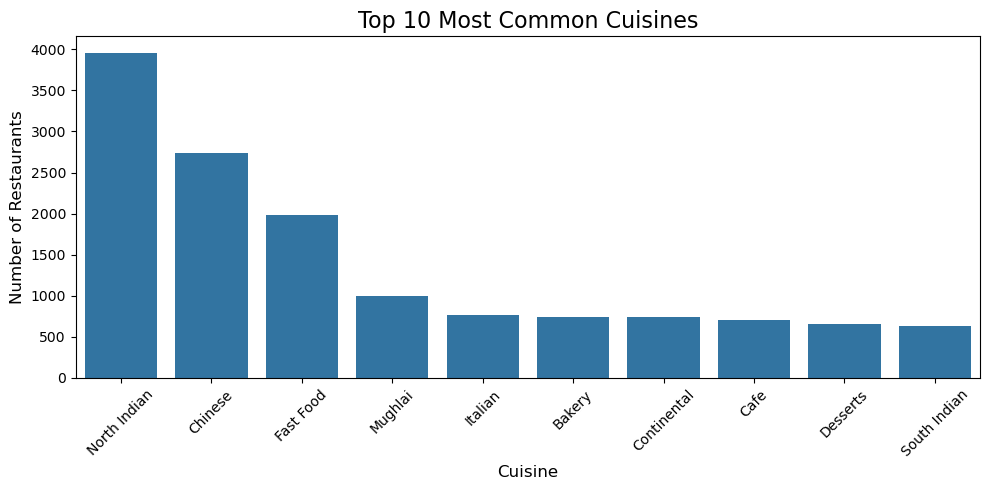

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Cuisine",
    y="Count",
    data=top_cuisine_df
)

plt.title("Top 10 Most Common Cuisines", fontsize=16)
plt.xlabel("Cuisine", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../charts/top_cuisines.png")
plt.show()

# Insights :

* North Indian cuisine appears most frequently in the dataset.
* Chinese and Fast Food cuisines are also highly popular.
* The dataset shows strong preference toward multi-cuisine restaurents.

## Conclusion

The analysis shows that North Indian cuisine is the most commonly served cuisine among restaurants in the dataset, followed by Chinese and Fast Food cuisines. This indicates a strong customer preference toward these cuisine categories.

# Task 2 - City Analysis

In this task, we analyze restaurant distribution across different cities and identify cities with the highest restaurant count and highest average ratings.

In [13]:
city_counts = df["City"].value_counts()
city_counts.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

In [14]:
top_city= city_counts.idxmax()
top_city_count=city_counts.max()
print("City with highest number of restaurents:",top_city)
print("Number of restaurents:",top_city_count)

City with highest number of restaurents: New Delhi
Number of restaurents: 5473


In [15]:
city_avg_rating=df.groupby("City")["Aggregate rating"].mean()
city_avg_rating=city_avg_rating.sort_values(ascending=False)
city_avg_rating.head(10)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64

In [16]:
highest_rating_city=city_avg_rating.idxmax()
highest_rating=city_avg_rating.max()
print("City with highest average rating:",highest_rating_city)
print("Average rating:",highest_rating)

City with highest average rating: Inner City
Average rating: 4.9


In [17]:
city_restaurent_count=df["City"].value_counts()
valid_cities=city_restaurent_count[city_restaurent_count>=20].index
filtered_df=df[df["City"].isin(valid_cities)]

In [18]:
filtered_city_rating = filtered_df.groupby("City")["Aggregate rating"].mean()

filtered_city_rating = filtered_city_rating.sort_values(ascending=False)

filtered_city_rating.head(10)

City
London            4.535
Orlando           4.475
Rest of Hawaii    4.410
Tampa Bay         4.410
Bangalore         4.375
Dubai             4.370
Chennai           4.315
Ankara            4.305
Abu Dhabi         4.300
Auckland          4.275
Name: Aggregate rating, dtype: float64

## Visualization: Top 10 Cities by Restaurant Count

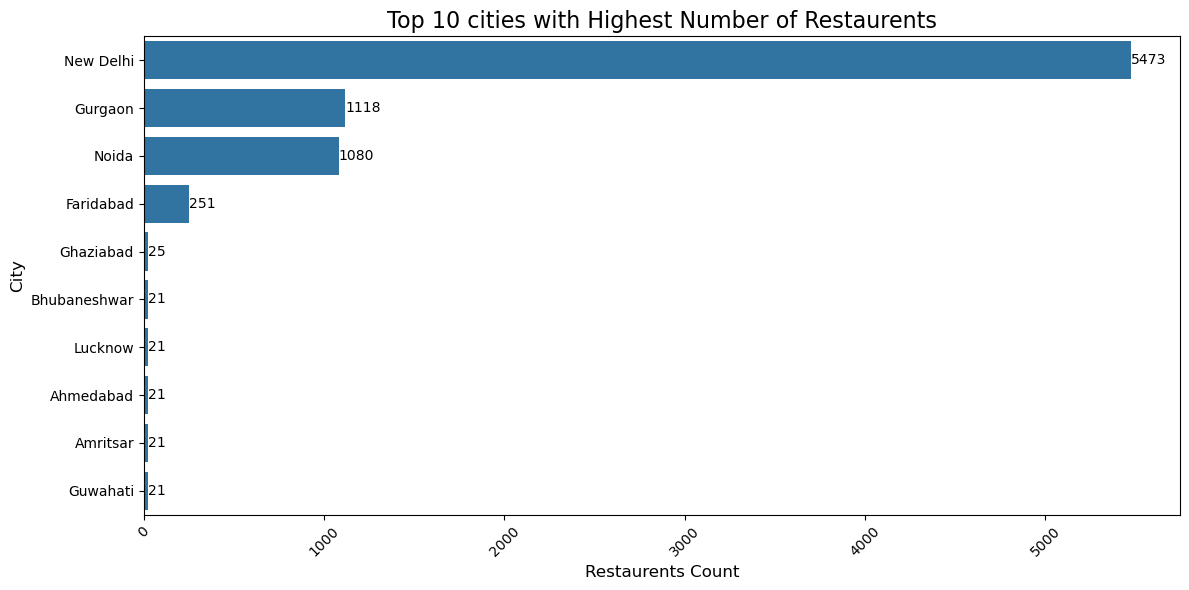

In [19]:
top_10_cities=city_counts.head(10)
plt.figure(figsize=(12,6))
ax=sns.barplot(
    x=top_10_cities.values,
    y=top_10_cities.index)
for i in ax.containers:
    ax.bar_label(i)
plt.title("Top 10 cities with Highest Number of Restaurents",fontsize=16)
plt.xlabel("Restaurents Count",fontsize=12)
plt.ylabel("City",fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/cities.png")
plt.show()


## Insights

- New Delhi contains the highest number of restaurants in the dataset.
- Some cities have higher average ratings despite having fewer restaurants.
- Filtering cities with very few restaurants gives more reliable rating analysis.
- New Delhi dominates the dataset significantly, indicating a strong regional concentration of restaurant data.
-  The dataset is highly concentrated toward New Delhi, which may influence overall analysis trends and results.

## Conclusion

The city analysis reveals that restaurant distribution is highly concentrated in a few major cities. Additionally, average restaurant ratings vary across cities, highlighting differences in customer satisfaction and restaurant quality.



# Task 3 — Price Range Distribution

In this task, we analyze the distribution of restaurant price ranges and identify the percentage of restaurants in each pricing category.

In [20]:
df["Price range"].value_counts()

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [21]:
price_counts=df["Price range"].value_counts().sort_index()
price_counts

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [22]:
price_percentage=(price_counts/len(df))*100
price_percentage

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64

In [23]:
price_df=pd.DataFrame({
    "Price Range":price_counts.index,
    "Restaurent Count":price_counts.values,
    "Percentage":price_percentage.values})
price_df

,Price Range,Restaurent Count,Percentage
0,1,4444,46.529159
1,2,3113,32.593446
2,3,1408,14.741912
3,4,586,6.135483


## Visualization: Price Range Distribution

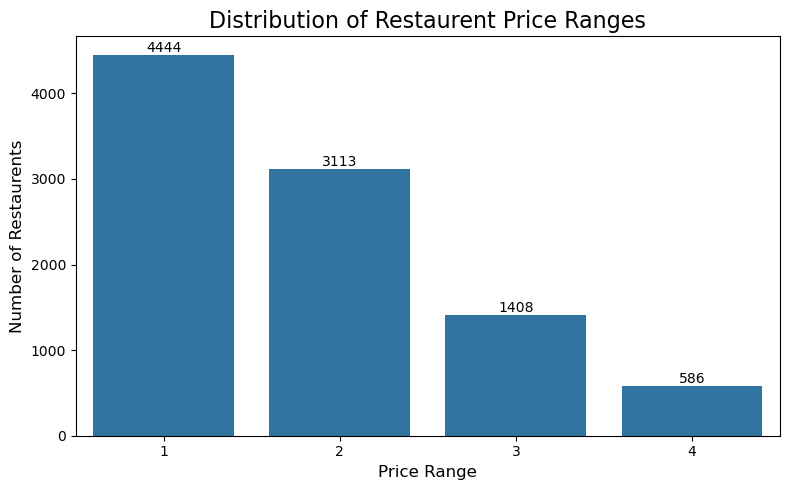

In [24]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Price Range",
    y="Restaurent Count",
    data=price_df
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Distribution of Restaurent Price Ranges", fontsize=16)

plt.xlabel("Price Range", fontsize=12)
plt.ylabel("Number of Restaurents", fontsize=12)

plt.tight_layout()

plt.savefig("../charts/price_range_distribution.png")

plt.show()

## Visualization: Percentage Distribution of Price Ranges

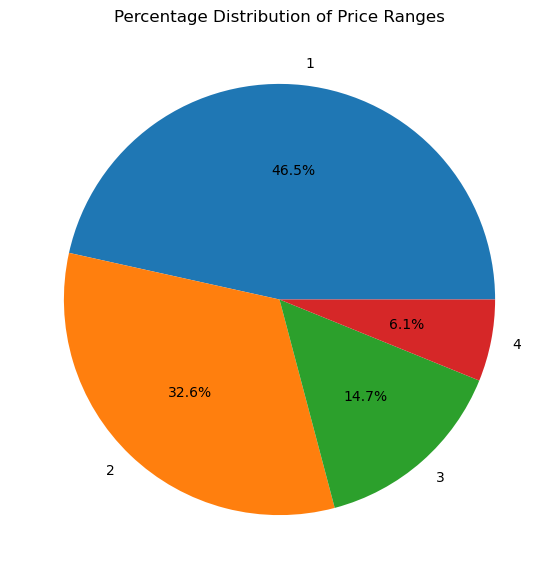

In [25]:
plt.figure(figsize=(7,7))

plt.pie(
    price_counts.values,
    labels=price_counts.index,
    autopct='%1.1f%%'
)

plt.title("Percentage Distribution of Price Ranges")

plt.savefig("../charts/price_range_pie.png")

plt.show()

## Insights

- Most restaurants fall under lower and mid-level price ranges.
- Very few restaurants belong to the highest price category.
- Affordable dining options dominate the dataset.
-  Nearly half of the restaurants belong to the low-price category, indicating strong market demand for affordable dining options.

## Conclusion

The price range analysis indicates that the majority of restaurants are concentrated in affordable and medium pricing categories, suggesting strong customer demand for budget-friendly dining options.

# Task 4 — Online Delivery Analysis

## Objective

To analyze the percentage of restaurants offering online delivery services and compare ratings between restaurants with and without online delivery.

In [26]:
df["Has Online delivery"].value_counts()

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

In [27]:
online_delivery_counts=df["Has Online delivery"].value_counts()
online_delivery_percentage=(online_delivery_counts/len(df))*100
online_delivery_percentage

Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64

In [28]:
delivery_df=pd.DataFrame({
    "Online Delivery": online_delivery_counts.index,
    "Count":online_delivery_counts.values,
    "Percentage": online_delivery_percentage.values
})
delivery_df

,Online Delivery,Count,Percentage
0,No,7100,74.337766
1,Yes,2451,25.662234


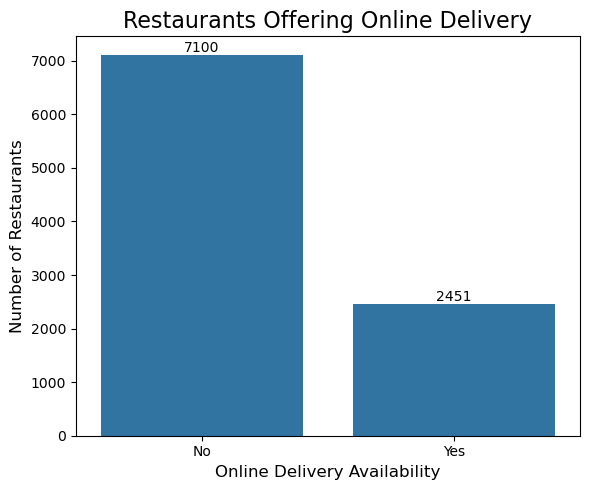

In [29]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x="Online Delivery",
    y="Count",
    data=delivery_df
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Restaurants Offering Online Delivery", fontsize=16)

plt.xlabel("Online Delivery Availability", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

plt.tight_layout()

plt.savefig("../charts/online_delivery_distribution.png")

plt.show()

In [30]:
delivery_rating = df.groupby(
    "Has Online delivery"
)["Aggregate rating"].mean()

delivery_rating

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

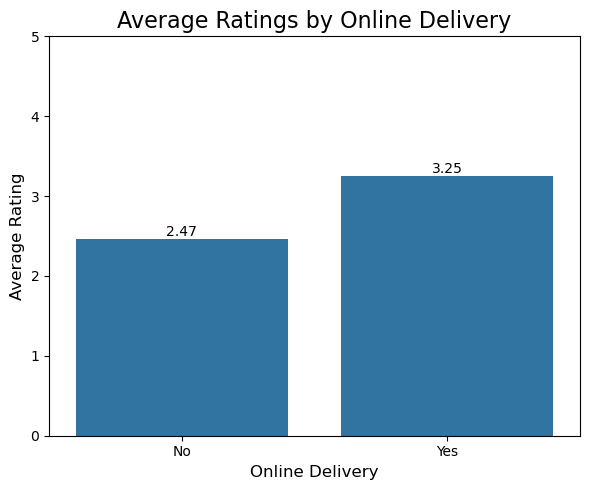

In [31]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=delivery_rating.index,
    y=delivery_rating.values
)

for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")
    
plt.ylim(0,5)

plt.title("Average Ratings by Online Delivery", fontsize=16)

plt.xlabel("Online Delivery", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)

plt.tight_layout()

plt.savefig("../charts/online_delivery_ratings.png")

plt.show()

## Insights

- Approximately 25% of restaurants offer online delivery services.
- Restaurants providing online delivery have higher average ratings compared to restaurants without delivery services.
- Online delivery may contribute positively to customer convenience and satisfaction.

## Conclusion

The analysis shows that online delivery services are associated with higher customer ratings, suggesting that convenience and accessibility play an important role in customer satisfaction.

# Level 2 — Task 3: Geographic Analysis

## Objective

To visualize restaurant locations using latitude and longitude and identify geographical distribution patterns.

In [32]:
df[["Latitude", "Longitude"]].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


In [33]:
df[["Latitude", "Longitude"]].isnull().sum()

Latitude     0
Longitude    0
dtype: int64

In [34]:
geo_df = df[
    (df["Latitude"] != 0) &
    (df["Longitude"] != 0)
]

geo_df.shape

(9052, 21)

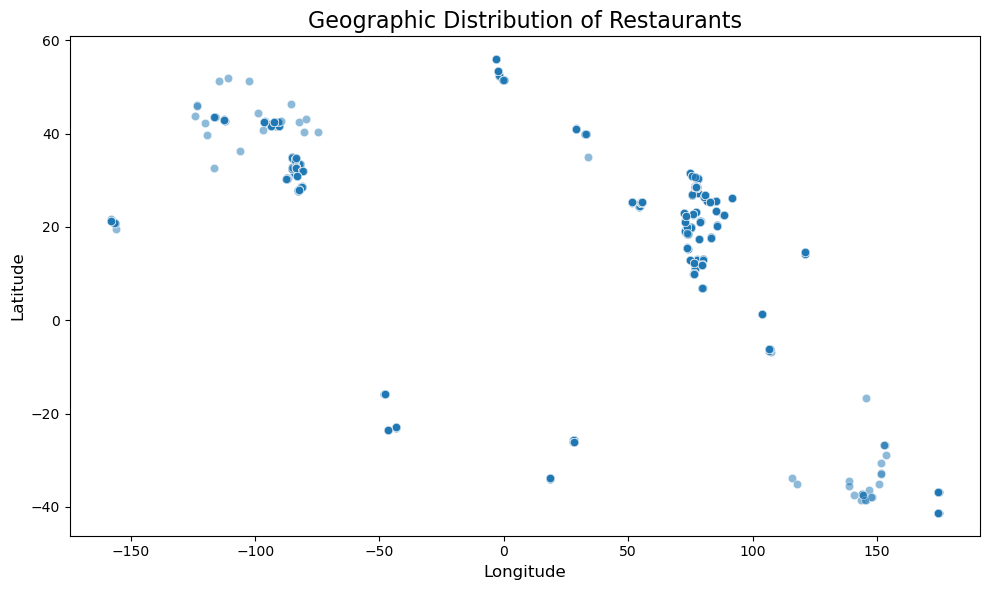

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Longitude",
    y="Latitude",
    data=geo_df,
    alpha=0.5
)

plt.title("Geographic Distribution of Restaurants", fontsize=16)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

plt.tight_layout()
plt.savefig("../charts/geographic_distribution.png")
plt.show()

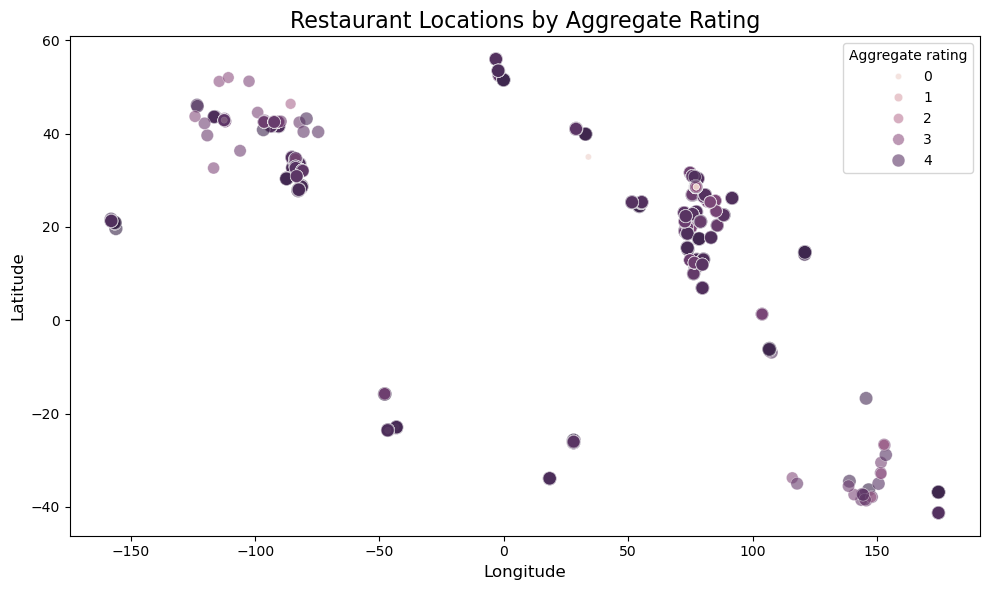

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Longitude",
    y="Latitude",
    data=geo_df,
    hue="Aggregate rating",
    size="Aggregate rating",
    sizes=(20, 100),
    alpha=0.6
)

plt.title("Restaurant Locations by Aggregate Rating", fontsize=16)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

plt.tight_layout()
plt.savefig("../charts/geographic_rating_distribution.png")
plt.show()

## Insights

- Restaurant locations are not evenly distributed across all regions.
- The dataset shows visible clustering in specific geographic areas.
- This indicates that restaurant presence is stronger in urban and high-demand locations.

## Conclusion

The geographic analysis shows that restaurants are concentrated in specific regions rather than being evenly spread. This suggests that restaurant businesses are more active in urban areas with higher customer demand.

# Level 2 — Task 2: Cuisine Combination Analysis

## Objective

To identify the most common cuisine combinations and analyze whether certain cuisine combinations receive higher restaurant ratings.

In [37]:
df["Cuisines"].head()

0          French, Japanese, Desserts
1                            Japanese
2    Seafood, Asian, Filipino, Indian
3                     Japanese, Sushi
4                    Japanese, Korean
Name: Cuisines, dtype: object

In [38]:
cuisine_combo_counts = df["Cuisines"].value_counts()

cuisine_combo_counts.head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [39]:
cuisine_combo_df = pd.DataFrame({
    "Cuisine Combination": cuisine_combo_counts.index,
    "Count": cuisine_combo_counts.values
})

cuisine_combo_df.head(10)

,Cuisine Combination,Count
0,North Indian,936
1,"North Indian, Chinese",511
2,Chinese,354
3,Fast Food,354
4,"North Indian, Mughlai",334
5,Cafe,299
6,Bakery,218
7,"North Indian, Mughlai, Chinese",197
8,"Bakery, Desserts",170
9,Street Food,149


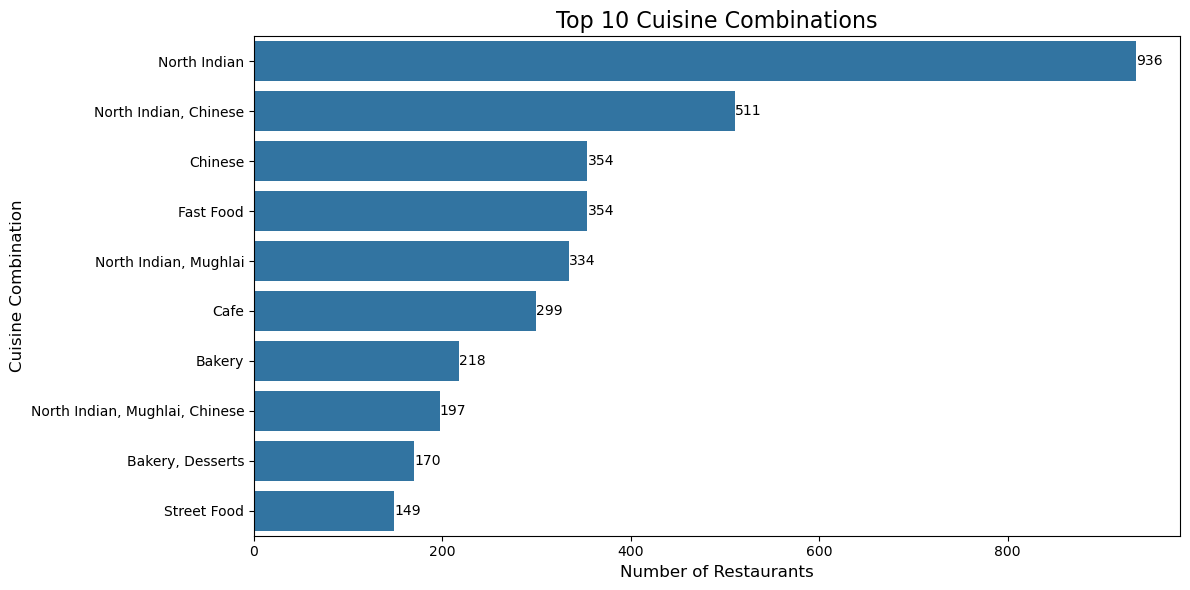

In [40]:
top_combos = cuisine_combo_df.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x="Count",
    y="Cuisine Combination",
    data=top_combos
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Top 10 Cuisine Combinations", fontsize=16)

plt.xlabel("Number of Restaurants", fontsize=12)
plt.ylabel("Cuisine Combination", fontsize=12)

plt.tight_layout()

plt.savefig("../charts/top_cuisine_combinations.png")

plt.show()

In [41]:
combo_ratings = df.groupby(
    "Cuisines"
)["Aggregate rating"].mean()

combo_ratings = combo_ratings.sort_values(
    ascending=False
)

combo_ratings.head(10)

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64

In [42]:
valid_combos = cuisine_combo_counts[
    cuisine_combo_counts >= 20
].index

In [43]:
filtered_combo_df = df[
    df["Cuisines"].isin(valid_combos)
]

In [44]:
filtered_combo_ratings = filtered_combo_df.groupby(
    "Cuisines"
)["Aggregate rating"].mean()

filtered_combo_ratings = filtered_combo_ratings.sort_values(
    ascending=False
)

filtered_combo_ratings.head(10)

Cuisines
American                       3.667742
Italian                        3.657407
Italian, Pizza                 3.637500
Mexican                        3.636111
Continental                    3.566667
Fast Food, Burger              3.403571
Cafe, Tea                      3.375000
Bakery, Desserts, Fast Food    3.366667
American, Fast Food            3.350000
Chinese, Thai                  3.309804
Name: Aggregate rating, dtype: float64

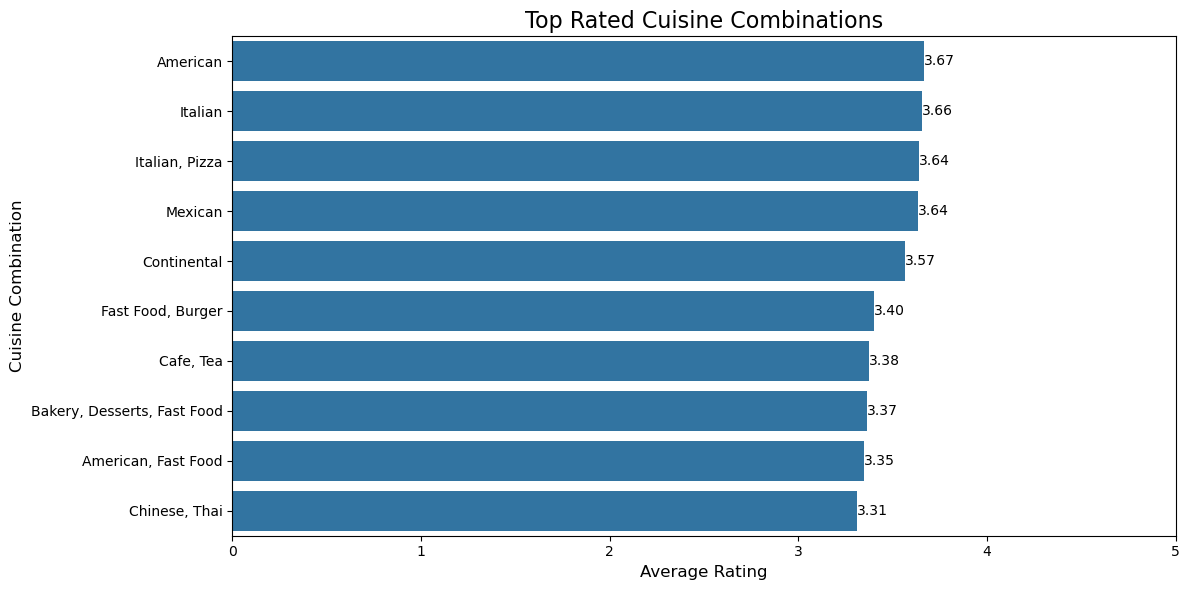

In [45]:
top_rated_combos = filtered_combo_ratings.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_rated_combos.values,
    y=top_rated_combos.index
)

for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

plt.title("Top Rated Cuisine Combinations", fontsize=16)

plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Cuisine Combination", fontsize=12)

plt.xlim(0,5)

plt.tight_layout()

plt.savefig("../charts/top_rated_cuisine_combinations.png")

plt.show()

## Insights

- Certain cuisine combinations are significantly more common than others.
- Multi-cuisine restaurants appear frequently in the dataset.
- Some cuisine combinations consistently receive higher customer ratings.

## Conclusion

Cuisine combination analysis reveals that customer preferences extend beyond single cuisines, with several multi-cuisine combinations achieving strong popularity and high customer ratings.

# Level 3 — Task 2: Votes Analysis

## Objective

To analyze the relationship between restaurant votes and aggregate ratings and identify restaurants with the highest and lowest votes.

In [46]:
df["Votes"].describe()

count     9551.000000
mean       156.909748
std        430.169145
min          0.000000
25%          5.000000
50%         31.000000
75%        131.000000
max      10934.000000
Name: Votes, dtype: float64

In [47]:
top_voted = df.sort_values(
    by="Votes",
    ascending=False
)

top_voted[[
    "Restaurant Name",
    "City",
    "Votes",
    "Aggregate rating"
]].head(10)

,Restaurant Name,City,Votes,Aggregate rating
728,Toit,Bangalore,10934,4.8
735,Truffles,Bangalore,9667,4.7
3994,Hauz Khas Social,New Delhi,7931,4.3
2412,Peter Cat,Kolkata,7574,4.3
739,AB's - Absolute Barbecues,Bangalore,6907,4.6
2414,Barbeque Nation,Kolkata,5966,4.9
743,Big Brewsky,Bangalore,5705,4.5
2307,AB's - Absolute Barbecues,Hyderabad,5434,4.9
736,The Black Pearl,Bangalore,5385,4.1
2411,BarBQ,Kolkata,5288,4.2


In [48]:
lowest_voted = df.sort_values(
    by="Votes",
    ascending=True
)

lowest_voted[[
    "Restaurant Name",
    "City",
    "Votes",
    "Aggregate rating"
]].head(10)

,Restaurant Name,City,Votes,Aggregate rating
1173,Aha Bites,Gurgaon,0,0.0
1172,Achoos Food Corner,Gurgaon,0,0.0
8558,Food Town,Noida,0,0.0
6165,Zaika Restaurant,New Delhi,0,0.0
6164,Smily Cakes,New Delhi,0,0.0
6161,Roll Junction,New Delhi,0,0.0
1178,Gopi Sweets & Caters,Gurgaon,0,0.0
1186,Tanishk Gourmet Indian,Gurgaon,0,0.0
1185,Solty Hotel,Gurgaon,0,0.0
1183,OMG Tiffinz,Gurgaon,0,0.0


In [49]:
correlation = df["Votes"].corr(
    df["Aggregate rating"]
)

print("Correlation between Votes and Ratings:", correlation)

Correlation between Votes and Ratings: 0.3136905841954117


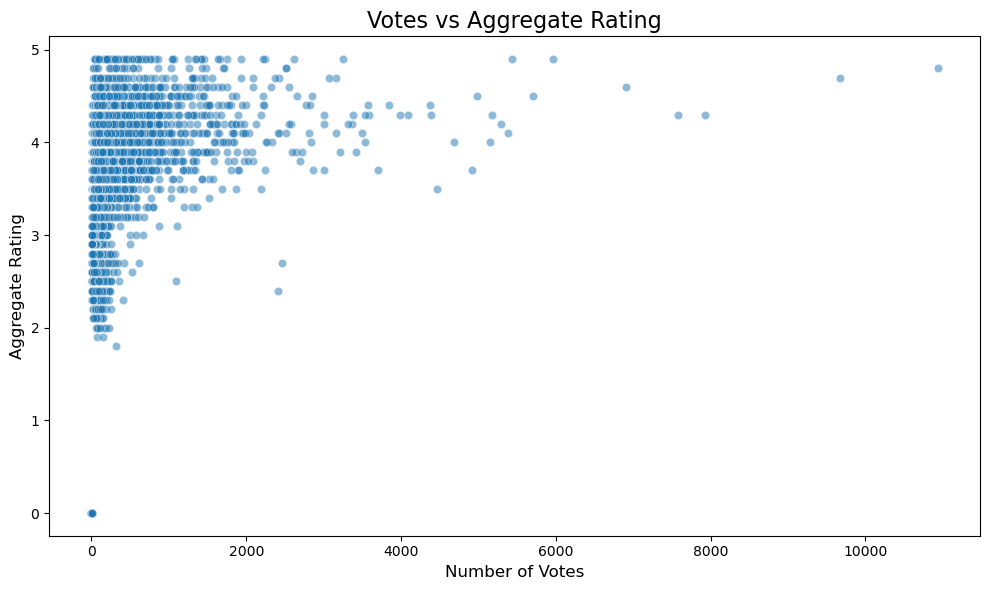

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Votes",
    y="Aggregate rating",
    data=df,
    alpha=0.5
)

plt.title("Votes vs Aggregate Rating", fontsize=16)

plt.xlabel("Number of Votes", fontsize=12)
plt.ylabel("Aggregate Rating", fontsize=12)

plt.tight_layout()

plt.savefig("../charts/votes_vs_ratings.png")

plt.show()

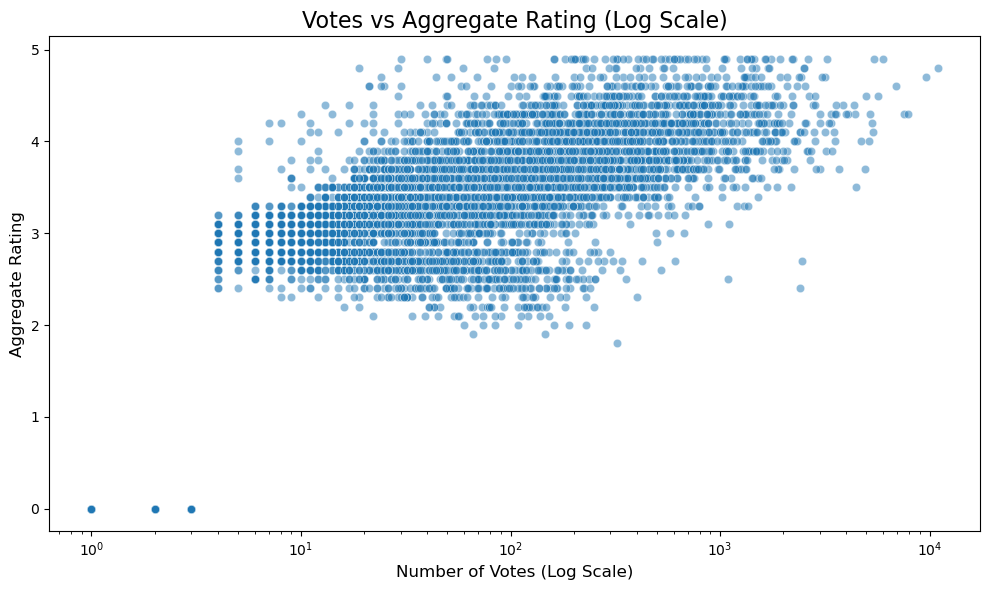

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Votes",
    y="Aggregate rating",
    data=df,
    alpha=0.5
)

plt.xscale("log")

plt.title("Votes vs Aggregate Rating (Log Scale)", fontsize=16)

plt.xlabel("Number of Votes (Log Scale)", fontsize=12)
plt.ylabel("Aggregate Rating", fontsize=12)

plt.tight_layout()

plt.savefig("../charts/votes_vs_ratings_logscale.png")

plt.show()

## Insights

- Restaurants with higher votes generally tend to have better ratings.
- Some restaurants achieve high ratings despite receiving fewer votes.
- The relationship between votes and ratings appears positively correlated.

## Conclusion

The votes analysis indicates a positive relationship between customer engagement and restaurant ratings. Restaurants with higher visibility and customer interaction often maintain stronger ratings.

# Final Conclusion

This project analyzed restaurant data using Python-based exploratory data analysis techniques. Multiple factors such as cuisine types, city distribution, pricing categories, online delivery services, geographic locations, and customer engagement were examined to derive business insights.

The analysis revealed that affordable restaurants dominate the dataset, online delivery services are associated with higher customer ratings, and restaurant distribution is heavily concentrated in metropolitan regions. Additionally, customer engagement measured through votes showed a positive relationship with restaurant ratings.

Overall, the project demonstrates the application of data cleaning, visualization, aggregation, and analytical reasoning techniques to extract meaningful insights from real-world restaurant data.